In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve, make_swiss_roll
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq


In [17]:

from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


In [18]:

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


### 1.1 IMS dataset
This time we will adopt the real dataset. The experiment will used the IMS dataset and also the phm2012 dataset.
First we will consider the IMS dataset, specifically the No.2 dataset No. 3 bearing (channel).


The test rig can be seen below:


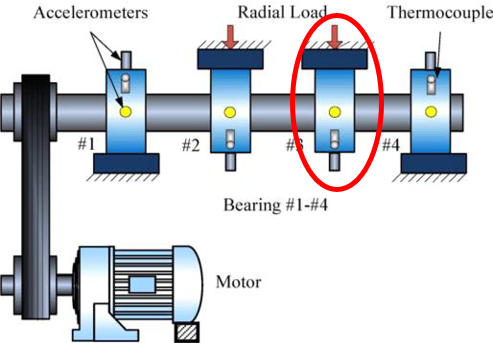



### Training the model using the time-domain data

In [19]:

import scipy.io as scio
from sklearn.model_selection import train_test_split
import pandas as pd

# dict_o = scio.loadmat(r'D:/Work in EPFL/diffusion_model/Ramanujan_Dictionary_DDPM/IMS_data/N2_data_C3_.mat')
#dict_o = pd.read_csv('AE_Diffusion/AE_data_ims/data_f.csv')
dict_oh = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_001.mat')
data_oh = dict_oh['a_y']
# y_oh = np.zeros(600,1)
dict_ou001 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_01.mat')
data_ou001 = dict_ou001['a_y']
dict_ou01 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_1.mat')
data_ou01 = dict_ou01['a_y']
dict_ou05 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_5.mat')
data_ou05 = dict_ou05['a_y']
dict_ou1 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_1_0.mat')
data_ou1 = dict_ou1['a_y']
dict_ou10 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_10_0.mat')
data_ou10 = dict_ou10['a_y']
dict_ou100 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_100_0.mat')
data_ou100 = dict_ou100['a_y']

def normalize(data):
    data_ = (data-np.min(data))/(np.max(data)-np.min(data))
    return data_
data_h_ = np.zeros((400,512))
data_u001 = np.zeros((400,512))
data_u01 = np.zeros((400,512))
data_u05 = np.zeros((400,512))
data_u1 = np.zeros((400,512))
data_u100 = np.zeros((400,512))
for i in range(400):
  data_h_[i,:] = normalize(data_oh[0,40*i:40*i+512])
  data_h_[i,:] = data_oh[0,40*i:40*i+512]
for i in range(400):
  data_u001[i,:] = normalize(data_ou001[0,40*i:40*i+512])
  data_u001[i,:] = data_ou001[0,40*i:40*i+512]
for i in range(400):
  data_u01[i,:] = normalize(data_ou01[0,40*i:40*i+512])
  data_u01[i,:] = data_ou01[0,40*i:40*i+512]
for i in range(400):
  data_u05[i,:] = normalize(data_ou05[0,40*i:40*i+512])
  data_u05[i,:] = data_ou05[0,40*i:40*i+512]
for i in range(400):
  data_u1[i,:] = normalize(data_ou1[0,40*i:40*i+512])
  data_u1[i,:] = data_ou1[0,40*i:40*i+512]
for i in range(400):
  data_u100[i,:] = normalize(data_ou100[0,40*i:40*i+512])
  data_u100[i,:] = data_ou100[0,40*i:40*i+512]

data_tva = np.vstack((data_h_,data_u001,data_u01,data_u05,data_u1))

data_tva = data_tva

data_tv = data_h_
# data_tv = np.vstack((data_h_,data_u100))
data_tv = data_tv
# data_test  = data_1[1000:-1,:,:]
yh = np.zeros(400)
# yu = np.ones(400)
y_ = yh
data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.2, random_state=42)
# data_tr = data_tr.view(-1,2048)
# data_va = data_va.view(-1,2048)

batch_size = 16 #考虑到样本总数仅为1000个,batch_size设定为64个
# dataset放到dataloader中
dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32),torch.tensor(y_1,dtype = torch.float32))
#dataloader_1 = torch.utils.data.DataLoader(torch.tensor(data_tr,dtype=torch.float32).cuda(), batch_size=batch_size, shuffle=True)
dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True)

In [20]:
# import scipy.io as scio
# from sklearn.model_selection import train_test_split
# import pandas as pd
# dict_ = scio.loadmat('AE_Diffusion/AE_data_ims/N2_data_C3_.mat')
# data_ = dict_['data_c3_']
# def normalize(data):
#     data_ = (data-np.min(data))/(np.max(data)-np.min(data))
#     return data_
# #data_h = np.random.randn(1000,4,1024)
# data_h = np.random.randn(1000,4096)
# # data_1 = np.random.randn(4920,4,1024)
# data_1 = np.random.randn(4920,4096)
# ii = 0
# for i in range(4920):
#   data_1[i,:] = normalize(data_[i,:])
#     # print(ii)
# data_h = data_1[0:1000,:]


In [21]:
# # data_b = data_1[4000:4920,:,:]
# # data_tv = np.concatenate((data_h, data_b),axis = 0)
# data_tv = data_h
# # data_test  = data_1[1000:-1,:,:]
# yh = np.zeros(1000)
# # yu = np.ones(920)
# # y_ = np.concatenate((yh,yu))
# y_ = yh
# data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.2, random_state=42)

# batch_size = 64 #考虑到样本总数仅为1000个,batch_size设定为64个
# # dataset放到dataloader中
# dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32).cuda(),torch.tensor(y_1,dtype = torch.float32).cuda())
# #dataloader_1 = torch.utils.data.DataLoader(torch.tensor(data_tr,dtype=torch.float32).cuda(), batch_size=batch_size, shuffle=True)
# dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True)



#### model construction

In [22]:
#针对Pytorch的数据归一化
def normalize(data):
    return (data-torch.min(data))/(torch.max(data)-torch.min(data))
def sample_idx(m,n):
    A=np.random.permutation(m)
    num=int(m/n)
    B=np.empty((num,n))
    for i in range(num):
        B[i,:]=A[n*i:n*(i+1)]
    idx=B.astype(int)
    return num,idx

b_size = 64 # 设定batch_size为32
L = 4096

# data_train_raw = torch.tensor(raw_data_1[:,0:200]).view(-1,200)
# data_train = torch.tensor(np.empty((L,int(20480/L)*200)))
# ii=0
# for i in range(200):
#     for j in range(int(20480/L)):
#         data_train[:,ii] = normalize(data_train_raw[(j)*L:(j+1)*L,i])
#         ii=ii+1
# num_train= 200*int(20480/L)


In [23]:
class Flatten(nn.Module):
    def forward(self, x):
        N, C, L = x.size()  # read in N, C, L
        z = x.view(N, -1)
#        print(C, L)
        return z  # "flatten" the C * L values into a single vector per image

class WDT_discriminator(nn.Module):
    def __init__(self,kernel_num1 = 32,kernel_num2 = 64,kernel_num3 = 128,kernel_num4 = 256,batch_size = 32 ):
        super().__init__()
        self.b_size = batch_size
        self.layers = nn.Sequential(
            nn.Conv1d(1,kernel_num1,kernel_size=25, stride=2),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Conv1d(kernel_num1,kernel_num2,kernel_size=25, stride=5),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Conv1d(kernel_num2,kernel_num3,kernel_size=25, stride=5),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Conv1d(kernel_num3,kernel_num4,kernel_size=25, stride=5),
            nn.LeakyReLU(0.01,inplace=True),
            Flatten()
        )
        self.layer2=nn.Sequential(
            nn.Linear(256*11,256),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Linear(256,1)
            # nn.LeakyReLU(0.01,inplace=True),
            # nn.Linear(32,1),
        )
        self.layers3 = nn.Sequential(
            nn.Linear(512,128),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Linear(128,32),
            nn.LeakyReLU(0.01,inplace=True),
            # nn.BatchNorm1d(64),
            nn.Linear(32,1)
            # nn.ReLU()
        )

    def forward(self,x):
        # x1=self.layers(x)
        # x2=self.layer2(x1)
        x3=self.layers3(x)
        return x3

# class Deflatten(nn.Module):
#     def forward(self, x):
#         N, L = x.size()  # read in N, C, L
#         z = x.view(N,1,-1)
# #        print(C, L)
#         return z  # "flatten" the C * L values into a single vector per image

class WDT_generator(nn.Module):
    def __init__(self,kernel_num1 = 128,kernel_num2 = 64,kernel_num3 = 32):
        super().__init__()
        self.dense=nn.Sequential(
            nn.Linear(100,4096),
            # nn.LeakyReLU(0.01,inplace=True),
            # nn.Linear(1024,4096),
            nn.LeakyReLU(0.01,inplace=True),
        )
        self.layers = nn.Sequential(
            nn.Linear(100,256),
            nn.LeakyReLU(0.01,inplace=True),
            nn.BatchNorm1d(256),
            nn.Linear(256,512),
            nn.LeakyReLU(0.01,inplace=True),
            nn.Dropout(p=0.5), #drop out 一般放在非线性激活层之后
            nn.Linear(512,512),
            nn.BatchNorm1d(512),
            nn.Sigmoid()
            # nn.ConvTranspose1d(512 ,128, kernel_size=25, stride=4,padding=1),
            # nn.LeakyReLU(0.01,inplace=True),
            # nn.ConvTranspose1d(128, 64, kernel_size=25, stride=4,dilation=2),
            # nn.LeakyReLU(0.01,inplace=True),
            # nn.ConvTranspose1d(64, 32, kernel_size=25, stride=4,output_padding=1),
            # nn.LeakyReLU(0.01,inplace=True),
            # nn.ConvTranspose1d(32,1, kernel_size=25, stride=4,output_padding=3),
            # nn.Sigmoid()
        )
    def forward(self,x):
        # x1=self.dense(x)
        # x2=x1.view(-1,512,8)

        return self.layers(x)

In [24]:
##施加梯度惩罚，来使得训练
def calc_gradient_penalty(netD, real_data, fake_data,BATCH_SIZE,LAMBDA):
    # print "real_data: ", real_data.size(), fake_data.size()
    use_gpu = False
    alpha = torch.rand(BATCH_SIZE,1,1)
    alpha = alpha.expand(real_data.size())
    #alpha = alpha.expand(BATCH_SIZE, real_data.nelement()/BATCH_SIZE).contiguous().view(BATCH_SIZE, 3, 32, 32)
    alpha = alpha.cuda() if use_gpu else alpha
    interpolates = alpha * real_data + ((1 - alpha) * fake_data)

    if use_gpu:
        interpolates = interpolates.cuda()
    interpolates = torch.autograd.Variable(interpolates, requires_grad=True)

    disc_interpolates = netD(interpolates.to(torch.float32))
    #disc_interpolates = discriminator(interpolates)

    gradients = torch.autograd.grad(outputs=disc_interpolates, inputs=interpolates,
                              grad_outputs=torch.ones(disc_interpolates.size()).cuda() if use_gpu else torch.ones(
                                  disc_interpolates.size()),
                              create_graph=True, retain_graph=True, only_inputs=True)[0]
    gradients = gradients.view(gradients.size(0), -1)

    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * LAMBDA
    return gradient_penalty

In [25]:

wdt_discriminator=WDT_discriminator()
wdt_generator=WDT_generator()
optimizer_g = torch.optim.Adam(wdt_generator.parameters(),lr=5e-5)
optimizer_d = torch.optim.Adam(wdt_discriminator.parameters(),lr=5e-5)

In [26]:
num_epoch = 1000
clip_value = 0.005
n_critic = 5
batches_done=0
num_train = 400
data_train = torch.tensor(data_h_,dtype = torch.float32)
data_vali = torch.tensor(data_tva,dtype = torch.float32)

#--------------------------
# torch.manual_seed(1)#为CPU设置随机种子
# torch.cuda.manual_seed(1)#为当前GPU设置随机种子
# torch.cuda.manual_seed_all(1)#为所有GPU设置随机种子
#--------------------------
wdt_generator.train()
wdt_discriminator.train()
for i in range(num_epoch):
    num,idx = sample_idx(num_train, b_size)
    for j in range(num):
        z_ = np.random.normal(0,1,(b_size, 100))
        z = torch.tensor(z_).to(torch.float32)
        # fake_data = wdt_generator(z).detach().view(b_size,1,-1)
        fake_data = wdt_generator(z).detach().view(b_size,1,-1)
        # real_data = data_train[:,idx[j,:].tolist()].view(b_size,1,-1).cuda()
        real_data = data_train[idx[j,:].tolist(),:].view(b_size,1,-1)
        optimizer_d.zero_grad()
        gradient_penalty = calc_gradient_penalty(wdt_discriminator,real_data,fake_data,b_size,LAMBDA=10)
        loss_D = -torch.mean(wdt_discriminator(real_data.to(torch.float32))) + torch.mean(wdt_discriminator(fake_data.to(torch.float32))) + gradient_penalty
        # loss_D = -torch.mean(torch.log(wdt_discriminator(real_data.to(torch.float32)))) - torch.mean(torch.log(1-wdt_discriminator(fake_data.to(torch.float32))))
        loss_D.backward()
        optimizer_d.step()
        # for p in wdt_discriminator.parameters():
        #     p.data.clamp_(-clip_value, clip_value)
        if j % n_critic == 0:
            optimizer_g.zero_grad()
            gen_imgs = wdt_generator(z)
            loss_G = -torch.mean(wdt_discriminator(gen_imgs.view(b_size,1,-1).to(torch.float32)))
            # loss_G = -torch.mean(torch.log(wdt_discriminator(gen_imgs.view(b_size,1,-1).to(torch.float32))))

            loss_G.backward()
            optimizer_g.step()

            # wdt_generator.eval()
            # z_t = torch.tensor(np.random.normal(0,1,(1, 100))).to(torch.float32).cuda()
            # generated_sample = wdt_generator(z_t).view(-1)
            # real_sample = data_train[:,0].view(-1)
            # y1 = generated_sample.cpu().detach().numpy()
            # y2 = real_sample.numpy()
            # x = np.linspace(0,1,L)

            # yf1 = abs(fft(y1))/L
            # yf2 = yf1[range(int(L/2+1))]
            # yf2[1:-1]=2*yf1[1:int(L/2)]
            # # f=(Fs/L)*np.arange(int(L/2+1))

            # yf1_ = abs(fft(y2))/L
            # yf2_ = yf1[range(int(L/2+1))]
            # yf2_[1:-1]=2*yf1_[1:int(L/2)]

            # cos_s = np.inner(yf2,yf2_)/(np.linalg.norm(yf2)*np.linalg.norm(yf2_))
            print(
                "[Epoch %d/%d]   [gradient_penalty %f] [D loss: %f] [G loss: %f]"
                % (i, num_epoch ,gradient_penalty.item(), loss_D.item(), loss_G.item())
            )

            wdt_generator.train()
        batches_done = batches_done+1
    # name_G = 'F:/python file/Wasserstein Digital Twin/ims_reset/ims_model_G_WF/G_'+str(i)+'.pth'
    # name_C = 'F:/python file/Wasserstein Digital Twin/ims_reset/ims_model_C_WF/C_'+str(i)+'.pth'
    # if i % 25 == 0:
    #     torch.save(wdt_generator,name_G)
    #     torch.save(wdt_discriminator,name_C)



[Epoch 0/1000]   [gradient_penalty 8.002471] [D loss: 7.992706] [G loss: -0.147873]
[Epoch 0/1000]   [gradient_penalty 7.823173] [D loss: 7.756676] [G loss: -0.092378]
[Epoch 1/1000]   [gradient_penalty 7.751317] [D loss: 7.674071] [G loss: -0.080936]
[Epoch 1/1000]   [gradient_penalty 7.618526] [D loss: 7.480353] [G loss: -0.020956]
[Epoch 2/1000]   [gradient_penalty 7.651403] [D loss: 7.502781] [G loss: -0.010278]
[Epoch 2/1000]   [gradient_penalty 7.456489] [D loss: 7.249609] [G loss: 0.046697]
[Epoch 3/1000]   [gradient_penalty 7.484759] [D loss: 7.263295] [G loss: 0.060656]
[Epoch 3/1000]   [gradient_penalty 7.299217] [D loss: 7.021335] [G loss: 0.120389]
[Epoch 4/1000]   [gradient_penalty 7.289403] [D loss: 6.996945] [G loss: 0.132391]
[Epoch 4/1000]   [gradient_penalty 7.086345] [D loss: 6.725659] [G loss: 0.201589]
[Epoch 5/1000]   [gradient_penalty 7.024772] [D loss: 6.650633] [G loss: 0.217067]
[Epoch 5/1000]   [gradient_penalty 6.896055] [D loss: 6.442092] [G loss: 0.299662]

In [27]:
#针对Pytorch的数据归一化
def normalize_t(data):
    return (data-torch.min(data))/(torch.max(data)-torch.min(data))
data_test= torch.tensor(data_tva,dtype = torch.float32).view(-1,1,512)
num_test = 2000
wdt_discriminator.eval()
HI_m_ = wdt_discriminator(data_test)

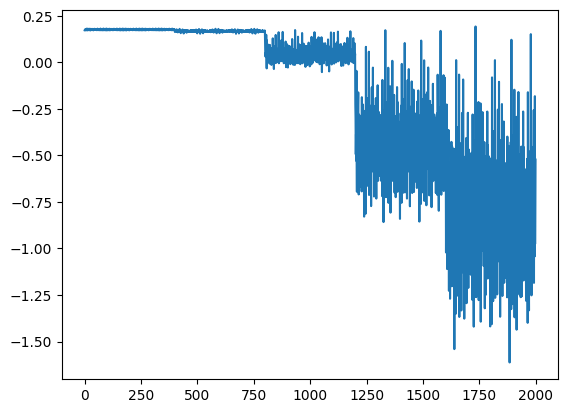

In [28]:
import matplotlib.pyplot as plt

HI_m = HI_m_.detach().cpu().numpy().reshape(-1)
plt.plot(HI_m)

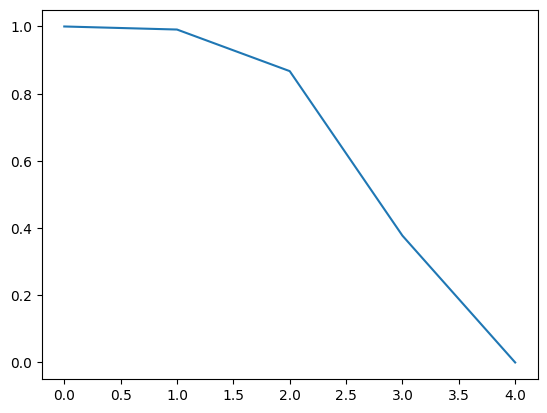

In [29]:
#针对numpy数组的标准化
def normalize_np(data):
    return (data-np.min(data))/(np.max(data)-np.min(data))
HI_t_ = np.ones(5)
HI_t = np.ones(5)
for i in range(5):
  HI_t_[i] = np.mean(HI_m[400*i:(i+1)*400])

HI_t = normalize_np(HI_t_)
plt.plot(HI_t)

In [31]:
import scipy.io as scio
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_WGAN-GP_simu(2).mat',{'HI_t':HI_t,'HI_t_':HI_t_})